E[Li] = P(Claim_i = 1) * E[Severity_i | Claim_i = 1]

Frequency Model: Use frequency data to train a classifier to predict the probability of filing claim
Severity Model: Use severity data to train a regression model to predict severity of claim for those who have already had an accident.
Multiply the predicted probability by the predicted severity to get the Expected Cost

Import packages

In [11]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import meteostat
from datetime import datetime
import polars as pl
import matplotlib.pyplot as plt
import holidays
import requests

Load the datasets

In [12]:
df_freq=pd.read_csv('consulting/frequency.csv')
df_sev=pd.read_csv('consulting/severity.csv')
print(df_freq.shape,df_sev.shape)

(24774, 11) (12256, 11)


In [13]:
df_freq.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1


In [14]:
df_sev.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746


Basic EDA

   Freq_Mean_Age  Sev_Mean_Age  Freq_Mean_CarVal  Sev_Mean_CarVal
0      38.554937     34.986945      16772.358521     17114.161635


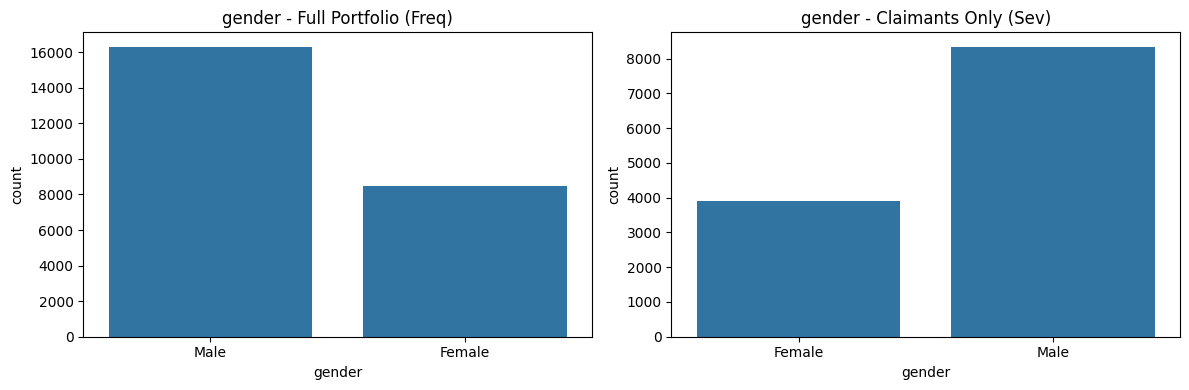

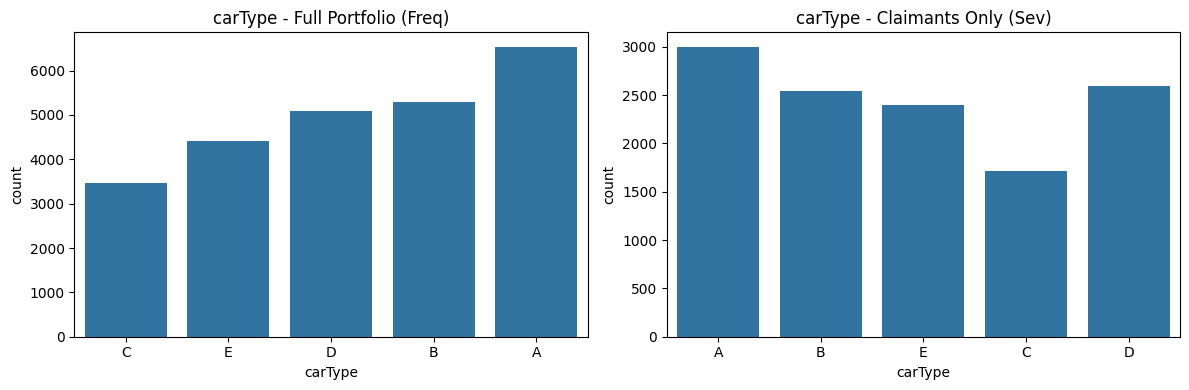

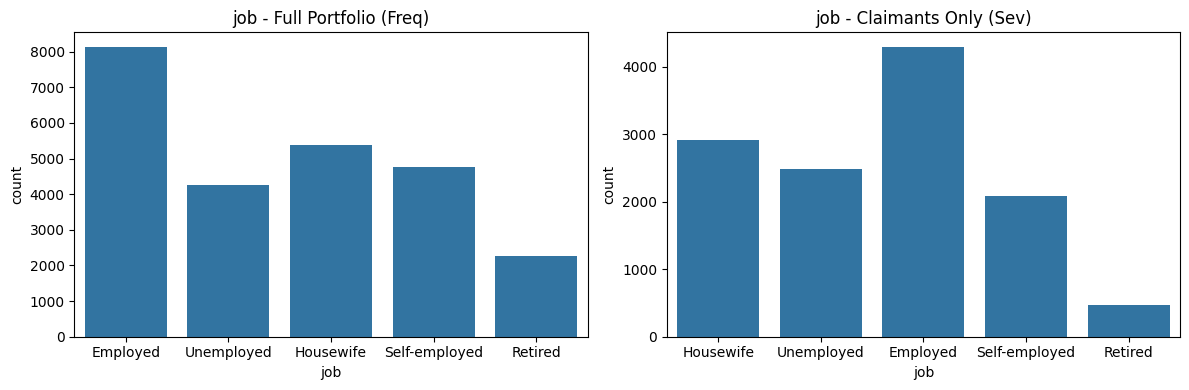

In [11]:
comparison = pd.DataFrame({
    'Freq_Mean_Age': [df_freq['age'].mean()],
    'Sev_Mean_Age': [df_sev['age'].mean()],
    'Freq_Mean_CarVal': [df_freq['carVal'].mean()],
    'Sev_Mean_CarVal': [df_sev['carVal'].mean()]
})
print(comparison)

def plot_categorical_dist(col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.countplot(data=df_freq, x=col, ax=ax[0])
    ax[0].set_title(f'{col} - Full Portfolio (Freq)')
    
    sns.countplot(data=df_sev, x=col, ax=ax[1])
    ax[1].set_title(f'{col} - Claimants Only (Sev)')
    
    plt.tight_layout()
    plt.show()

for col in ['gender', 'carType', 'job']:
    plot_categorical_dist(col)

Claimants are younger than the general portfolio meaning younger drivers may be higher risk -- find literature on this?
Car Values are very close so might not have as strong an effect maybe for claim filing

Portfolio and claimants are heavily Male but there is a bias in the portfolio itself
Retirees are a decent chunk of the portfolio but a tiny sliver of claimants -- maybe they drive less or more safer (same age factor at play here)

carType A is the most common in both


Overall Portfolio Claim Rate: 49.56%


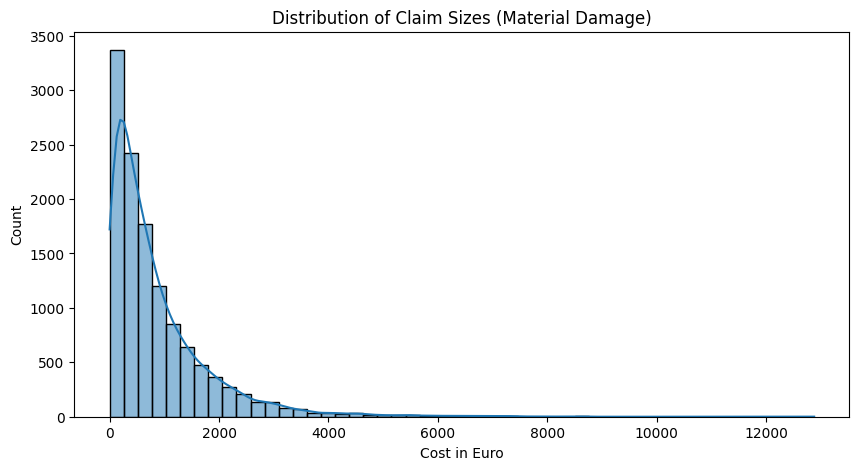

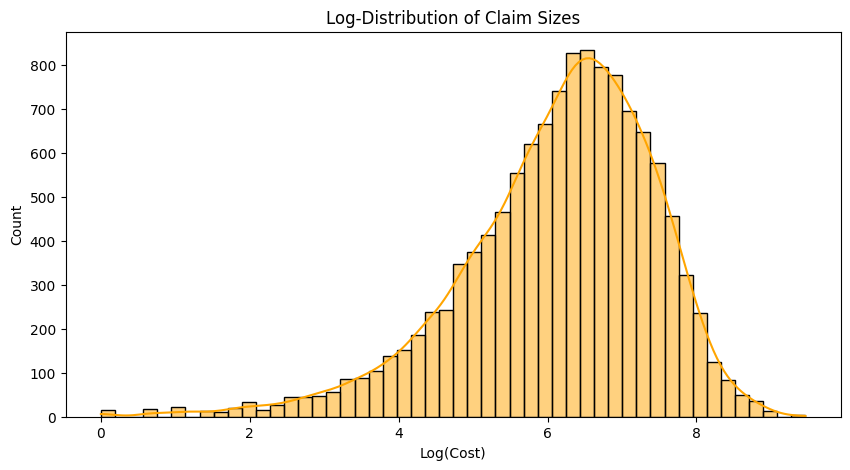

In [12]:
claim_rate = df_freq['claimNumbMD'].mean()
print(f"\nOverall Portfolio Claim Rate: {claim_rate:.2%}")

plt.figure(figsize=(10, 5))
sns.histplot(df_sev['claimSizeMD'], bins=50, kde=True)
plt.title("Distribution of Claim Sizes (Material Damage)")
plt.xlabel("Cost in Euro")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log(df_sev['claimSizeMD']), bins=50, kde=True, color='orange')
plt.title("Log-Distribution of Claim Sizes")
plt.xlabel("Log(Cost)")
plt.show()

heavy Right Skew meaning most claims are small but with a long tail of expensive claims
Log-Distribution is nearly a Bell Curve - Gamma GLM with a Log-link or a Log-Normal model?

Data Cleaning

Missing Values in Frequency Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimNumbMD    0
dtype: int64

Missing Values in Severity Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimSizeMD    0
dtype: int64

Health Check Summary:
{'Min Age': 18, 'Max Age': 75, 'Zero/Negative Claims': 4, 'Max Claim': 12878, 'Freq_Number of Years Min': 0, 'Freq_Number of Years Max': 15, 'Sev_Number of Years Min': 0, 'Sev_Number of Years Max': 15, 'Freq_Density Min': 14.37714238, 'Freq_Density Max': 297.3851697, 'Sev_Density Min': 14, 'Sev_Density Max': 297}


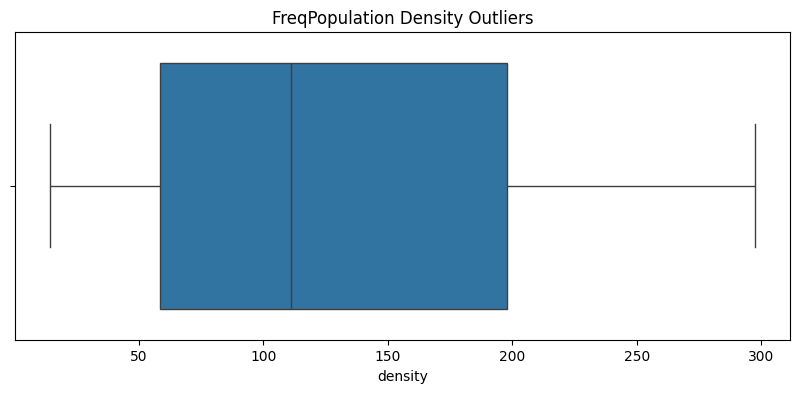

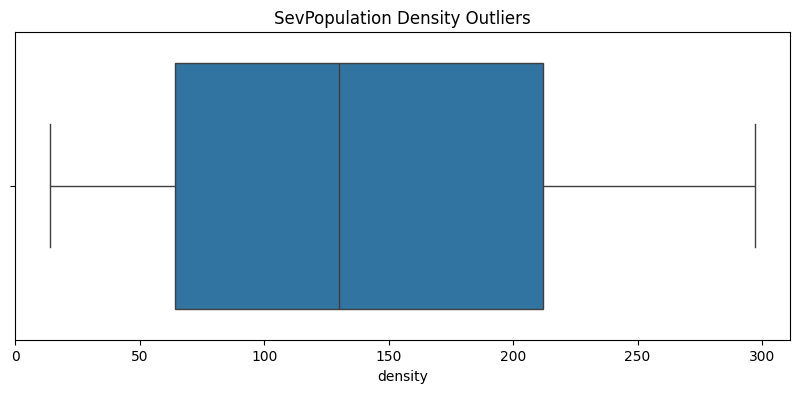

In [15]:
print("Missing Values in Frequency Data:")
print(df_freq.isnull().sum())

print("\nMissing Values in Severity Data:")
print(df_sev.isnull().sum())

health_check = {
    "Min Age": df_freq['age'].min(),
    "Max Age": df_freq['age'].max(),
    "Zero/Negative Claims": (df_sev['claimSizeMD'] <= 0).sum(),
    "Max Claim": df_sev['claimSizeMD'].max(),
    "Freq_Number of Years Min" : df_freq['nYears'].min(),
    "Freq_Number of Years Max" : df_freq['nYears'].max(),
    "Sev_Number of Years Min" : df_sev['nYears'].min(),
    "Sev_Number of Years Max" : df_sev['nYears'].max(),
    "Freq_Density Min" : df_freq['density'].min(),
    "Freq_Density Max" : df_freq['density'].max(),
    "Sev_Density Min" : df_sev['density'].min(),
    "Sev_Density Max" : df_sev['density'].max(),
}
print("\nHealth Check Summary:")
print(health_check)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_freq['density'])
plt.title("FreqPopulation Density Outliers")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sev['density'])
plt.title("SevPopulation Density Outliers")
plt.show()

No Missing Values for both datasets.
4 records where claimSizeMD is 0 out of 12,256 claimants and must be handled since Gamma  and Log-links cannot process 0
Age range is sensible (18 to 75) 
nYears - mix of new and loyal customers (0 to 15)

Density - no extreme outliers
Claim Max: 12,878 Euro is a significant but not impossible car repair bill

Feature Engineering

In [15]:
df_sev = df_sev[df_sev['claimSizeMD'] > 0].copy()

def engineer_features(df):
    df['is_young'] = (df['age'] < 25).astype(int)
    df['driving_years'] = df['age'] - 18
    df['loyalty_index'] = df['nYears'] / (df['age'] - 17) 
    
    df['log_carVal'] = np.log1p(df['carVal'])
    df['log_density'] = np.log1p(df['density'])
    avg_val_cat = df.groupby('carCat')['carVal'].transform('mean')
    df['relative_car_val'] = df['carVal'] / avg_val_cat
    
    df['val_density_interaction'] = df['log_carVal'] * df['log_density']
    df['is_new_policy'] = (df['nYears'] == 0).astype(int)

    cat_cols = ['gender', 'carType', 'carCat', 'job', 'cover']
    for col in cat_cols:
        df[col] = df[col].astype(str)

    df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

    return df


freq_eng = engineer_features(df_freq)
sev_eng = engineer_features(df_sev)


In [16]:
freq_eng.head(5)

,uwYear,age,nYears,carVal,density,claimNumbMD,is_young,driving_years,loyalty_index,log_carVal,...,carType_C,carType_D,carType_E,carCat_Medium,carCat_Small,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,cover_1
0,2009,25,3,15080,72.012883,1,0,7,0.375000,9.621191,...,1,0,0,0,0,0,0,0,0,0
1,2009,20,2,22370,39.550411,1,1,2,0.666667,10.015521,...,0,0,1,0,0,0,0,0,0,1
2,2009,42,0,39650,169.529148,1,0,24,0.000000,10.587871,...,0,0,1,0,0,0,0,0,1,0
3,2009,21,0,12600,58.894688,1,1,3,0.000000,9.441531,...,1,0,0,1,0,1,0,0,0,1
4,2009,33,10,9065,109.631885,1,0,15,0.625000,9.112286,...,0,1,0,0,0,0,0,0,0,0


In [25]:
analysis = freq_eng.groupby('is_new_policy')['claimNumbMD'].mean()
print("Claim Rate - New vs Existing Policies:")
print(analysis)

Claim Rate - New vs Existing Policies:
is_new_policy
0    0.484375
1    0.558903
Name: claimNumbMD, dtype: float64


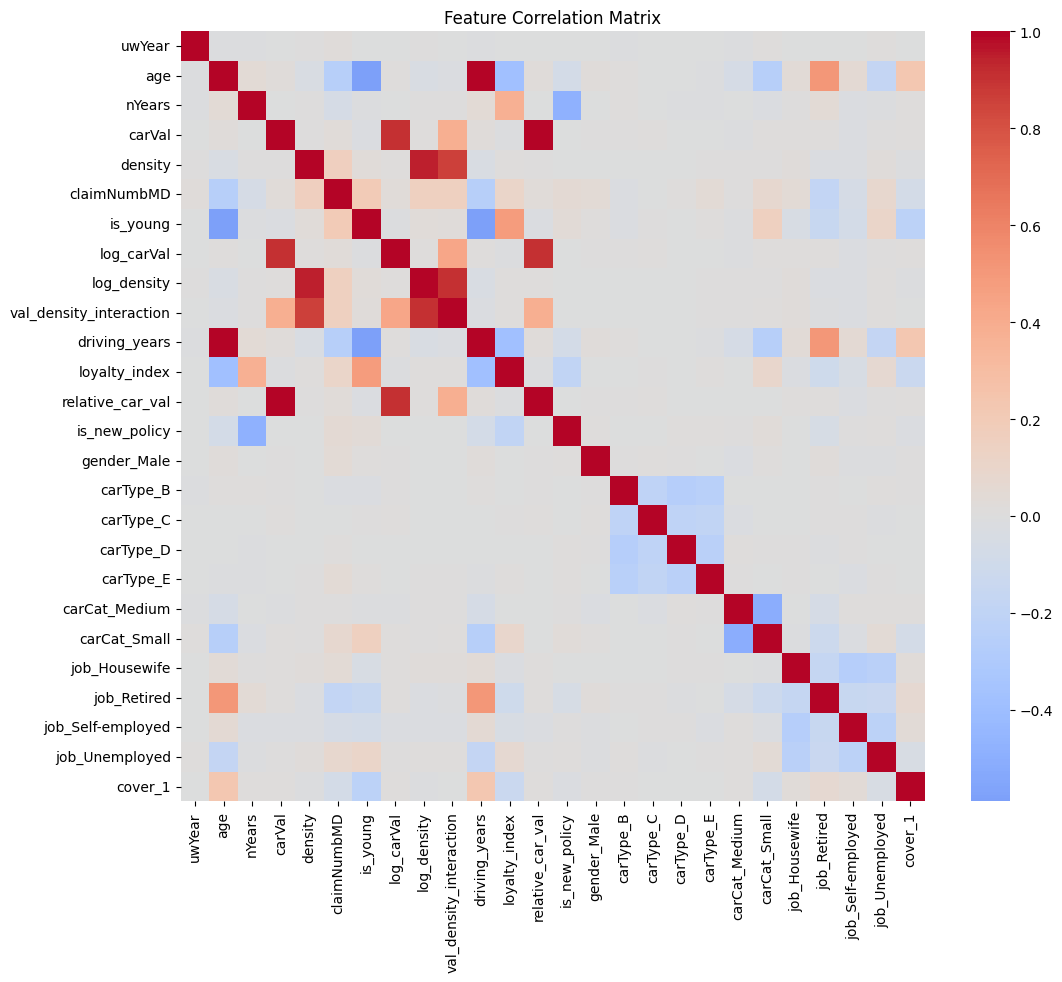

age               driving_years       1.000000
cover_1           cover_1             1.000000
relative_car_val  carVal              0.999957
carVal            relative_car_val    0.999957
log_density       density             0.950344
density           log_density         0.950344
log_carVal        carVal              0.908933
carVal            log_carVal          0.908933
log_carVal        relative_car_val    0.908904
relative_car_val  log_carVal          0.908904
dtype: float64


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = freq_eng.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False)
print(high_corr[len(freq_eng.columns) : len(freq_eng.columns) + 10])

probably drop carVal and , log_CarVal and density?

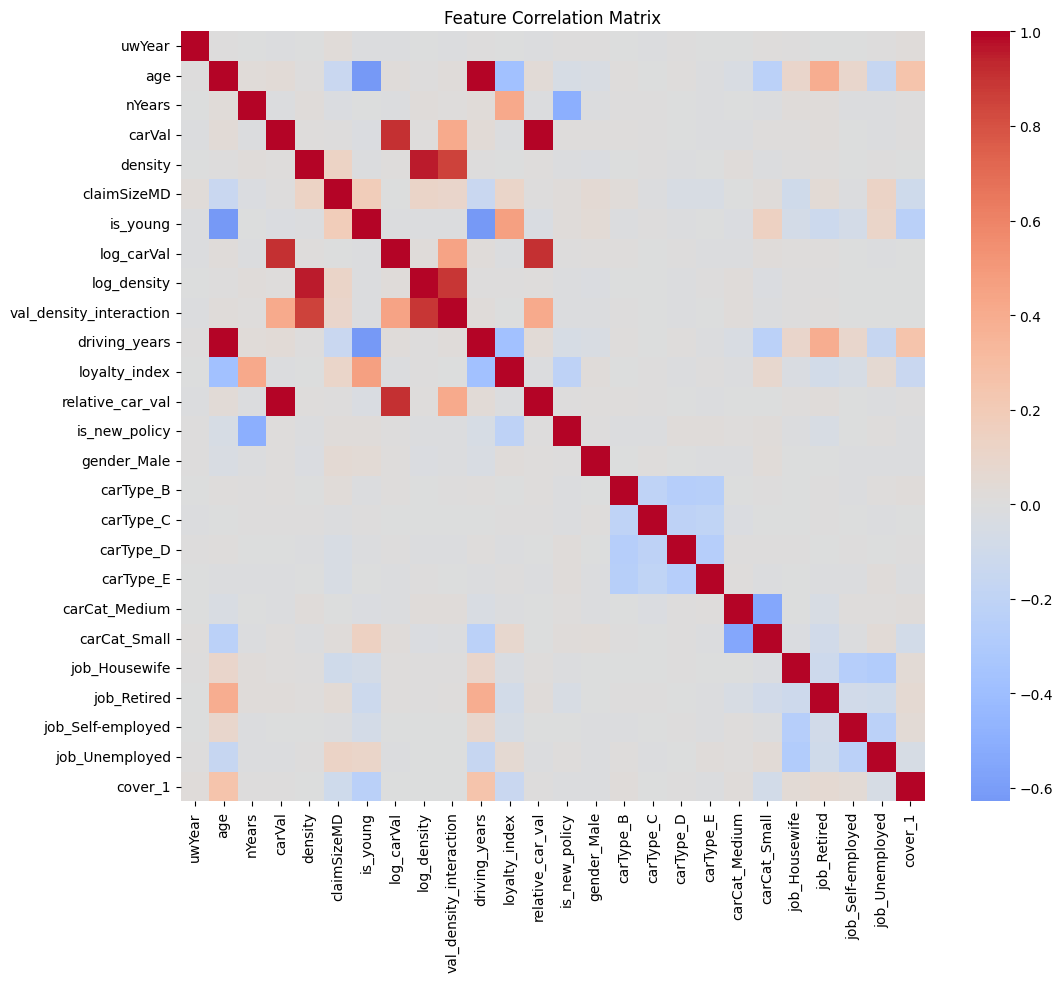

age               driving_years       1.000000
cover_1           cover_1             1.000000
carVal            relative_car_val    0.999914
relative_car_val  carVal              0.999914
log_density       density             0.951383
density           log_density         0.951383
carVal            log_carVal          0.909896
log_carVal        carVal              0.909896
relative_car_val  log_carVal          0.909792
log_carVal        relative_car_val    0.909792
dtype: float64


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = sev_eng.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False)
print(high_corr[len(sev_eng.columns) : len(sev_eng.columns) + 10])

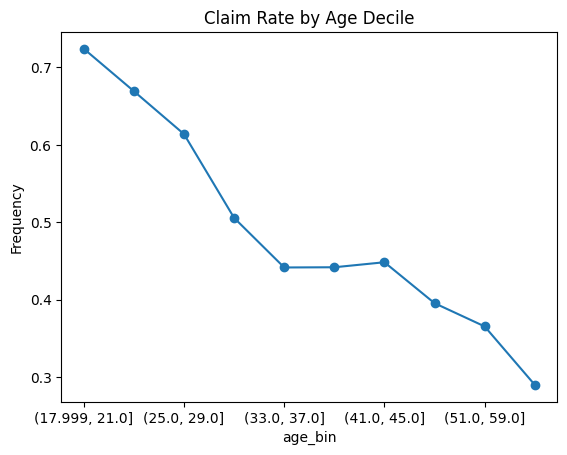

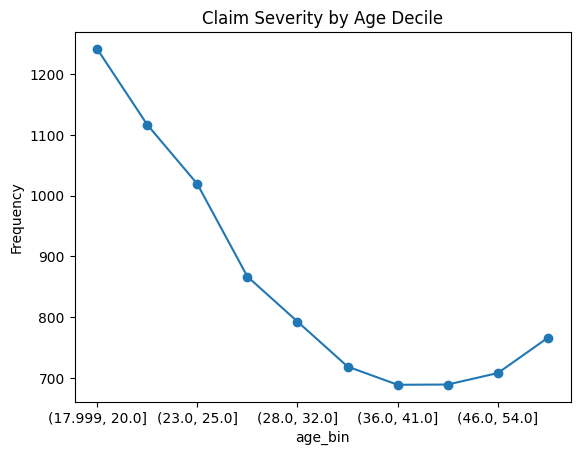

In [17]:
# Binning Age to check for the 'U-Shape'
freq_eng['age_bin'] = pd.qcut(freq_eng['age'], q=10)
age_profile = freq_eng.groupby('age_bin')['claimNumbMD'].mean()
sev_eng['age_bin'] = pd.qcut(sev_eng['age'], q=10)
age_profile_sev = sev_eng.groupby('age_bin')['claimSizeMD'].mean()

age_profile.plot(kind='line', marker='o')
plt.title("Claim Rate by Age Decile")
plt.ylabel("Frequency")
plt.show()

age_profile_sev.plot(kind='line', marker='o')
plt.title("Claim Severity by Age Decile")
plt.ylabel("Frequency")
plt.show()

In [25]:
def calculate_woe_iv(df, feature, target):
    if df[feature].nunique() > 10:
        df['temp_bin'] = pd.qcut(df[feature], q=10, duplicates='drop')
    else:
        df['temp_bin'] = df[feature]
        
    stats = df.groupby('temp_bin')[target].agg(['count', 'sum'])
    stats.columns = ['Total', 'Claims']
    stats['Non-Claims'] = stats['Total'] - stats['Claims']
    
    perc_claims = stats['Claims'] / stats['Claims'].sum()
    perc_non_claims = stats['Non-Claims'] / stats['Non-Claims'].sum()
    
    stats['WoE'] = np.log((perc_claims + 0.0001) / (perc_non_claims + 0.0001))
    stats['IV'] = (perc_claims - perc_non_claims) * stats['WoE']
    
    total_iv = stats['IV'].sum()
    return total_iv, stats[['WoE', 'IV']]

for col in ['age', 'log_density', 'carVal', 'nYears']:
    iv, table = calculate_woe_iv(freq_eng, col, 'claimNumbMD')
    print(f"Information Value for {col}: {iv:.4f}")


Information Value for age: 0.2984
Information Value for log_density: 0.1067
Information Value for carVal: 0.0051
Information Value for nYears: 0.0143


In [30]:
# keep log_density and age 
# drop carVal because its IV (0.0051) is basically zero 
cols_to_drop_freq = ['log_carVal', 'density','relative_car_val','temp_bin']

df_freq_fin = freq_eng.drop(columns=cols_to_drop_freq)

# drop density and log_density 
cols_to_drop_sev = ['density', 'relative_car_val','log_carVal'] 

df_sev_fin = sev_eng.drop(columns=cols_to_drop_sev)

print(f"Frequency features remaining: {len(df_freq_fin.columns)}")
print(f"Severity features remaining: {len(df_sev_fin.columns)}")

Frequency features remaining: 24
Severity features remaining: 24


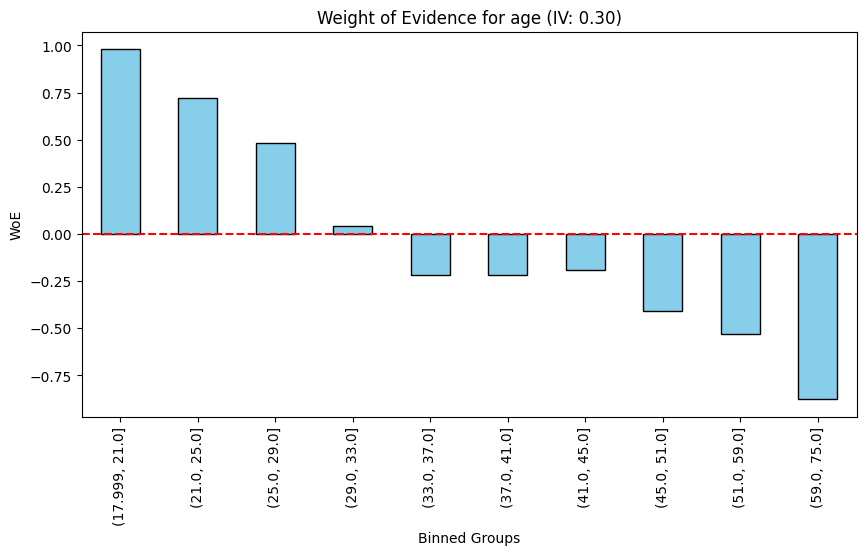

In [27]:
def plot_woe(df, feature, target):
    iv, stats = calculate_woe_iv(df, feature, target)
    
    plt.figure(figsize=(10, 5))
    stats['WoE'].plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Weight of Evidence for {feature} (IV: {iv:.2f})")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.ylabel("WoE")
    plt.xlabel("Binned Groups")
    plt.show()

plot_woe(df_freq_fin, 'age', 'claimNumbMD')

In [29]:
print("Final Frequency Columns:", df_freq_fin.columns.tolist())
print("\nFinal Severity Columns:", df_sev_fin.columns.tolist())

Final Frequency Columns: ['uwYear', 'age', 'nYears', 'carVal', 'claimNumbMD', 'is_young', 'driving_years', 'loyalty_index', 'log_density', 'val_density_interaction', 'is_new_policy', 'gender_Male', 'carType_B', 'carType_C', 'carType_D', 'carType_E', 'carCat_Medium', 'carCat_Small', 'job_Housewife', 'job_Retired', 'job_Self-employed', 'job_Unemployed', 'cover_1', 'age_bin', 'temp_bin']

Final Severity Columns: ['uwYear', 'age', 'nYears', 'carVal', 'claimSizeMD', 'is_young', 'driving_years', 'loyalty_index', 'log_density', 'val_density_interaction', 'is_new_policy', 'gender_Male', 'carType_B', 'carType_C', 'carType_D', 'carType_E', 'carCat_Medium', 'carCat_Small', 'job_Housewife', 'job_Retired', 'job_Self-employed', 'job_Unemployed', 'cover_1', 'age_bin']


In [38]:
cols_to_exclude = ['claimNumbMD', 'uwYear', 'age_bin', 'temp_bin']
extra_objects_freq = df_freq_fin.select_dtypes(include=['object', 'category']).columns.tolist()
final_drop_freq = list(set(cols_to_exclude + extra_objects_freq))
cols_to_exclude_sev = ['claimSizeMD', 'uwYear', 'age_bin', 'temp_bin']
extra_objects_sev = df_sev_fin.select_dtypes(include=['object', 'category']).columns.tolist()
final_drop_sev = list(set(cols_to_exclude_sev + extra_objects_sev))


import statsmodels.api as sm

# Logistic Regression
X_freq = df_freq_fin.drop(columns=[c for c in final_drop_freq if c in df_freq_fin.columns])
X_freq = sm.add_constant(X_freq).astype(float) 
y_freq = df_freq_fin['claimNumbMD'].astype(int)


model_freq = sm.GLM(y_freq, X_freq, family=sm.families.Binomial()).fit()

# Gamma GLM log link to ensure predicted costs are always positive
X_sev = df_sev_fin.drop(columns=[c for c in final_drop_sev if c in df_sev_fin.columns])
X_sev = sm.add_constant(X_sev).astype(float)
y_sev = df_sev_fin['claimSizeMD'].astype(float)

model_sev = sm.GLM(y_sev, X_sev, family=sm.families.Gamma(link=sm.families.links.log())).fit()

# score the entire portfolio 
portfolio_scoring = sm.add_constant(df_freq_fin.drop(columns=['claimNumbMD', 'uwYear','age_bin']))
portfolio_sev_scoring = sm.add_constant(df_freq_fin[X_sev.columns.drop('const')])

freq_preds = model_freq.predict(portfolio_scoring)
df_freq_fin['expected_frequency']=freq_preds
sev_preds = model_sev.predict(portfolio_sev_scoring)
df_sev_fin['expected_sev']=sev_preds

df_freq_fin['expected_loss'] = freq_preds * sev_preds

# Rank them - Top 10% are the 'Unprofitable' targets
unprofitable = df_freq_fin.sort_values('expected_loss', ascending=False).head(int(len(df_freq_fin)*0.1))

print("Top 5 Highest Risk Customers:")
print(unprofitable[['age', 'expected_loss']].head())

Top 5 Highest Risk Customers:
       age  expected_loss
9500    18    1987.593256
10423   18    1884.215278
9833    18    1853.969562
2277    18    1853.295252
6118    18    1830.088174


In [39]:
avg_loss = df_freq_fin['expected_loss'].mean()
top_avg_loss = unprofitable['expected_loss'].mean()
risk_multiplier = top_avg_loss / avg_loss

print(f"Portfolio Average Expected Loss: {avg_loss:.2f} Euro")
print(f"Top 10% Average Expected Loss: {top_avg_loss:.2f} Euro")
print(f"The top 10% are {risk_multiplier:.1f}x riskier than the average customer.")

Portfolio Average Expected Loss: 428.76 Euro
Top 10% Average Expected Loss: 995.11 Euro
The top 10% are 2.3x riskier than the average customer.


hurdle was linking frequency and severity                                                                                                             To overcome this, we built a Two-Part Frequency-Severity Model (Tweedie-style) using shared covariates                                           removed 4 zero-value claims from the severity data since Gamma GLMs and Log-links cannot process zero/negative values                            Binomial GLM with a Logit link was used as the target was a binary indicator of whether an accident occurred                                       Used a Gamma GLM with a Log link as it corrects for the right-skewed nature of repair costs and ensures all predictions are positive                  Log-transformations to density and carVal to normalize their distributions                                                                 is_new_policy indicator which had a higher claim frequency                                                                                          One-Hot Encoding for categorical variables                                                                                                     Unprofitability or Expected Loss was calculated and the portfolio was ranked to identify high-risk customers                                     segment is dominated by young drivers (age 18) and new policyholders                                                                             Apply a significant premium increase to the top 10% of customers identified by the model                                                            For the high-frequency/low-severity group, increase the mandatory deductible                                                                          Use the findings to tighten acceptance criteria for the upcoming year.

Different Modelling Approaches

In [40]:
df_freq_fin.head(5)

,uwYear,age,nYears,carVal,claimNumbMD,is_young,driving_years,loyalty_index,log_density,val_density_interaction,...,carCat_Medium,carCat_Small,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,cover_1,age_bin,expected_frequency,expected_loss
0,2009,25,3,15080,1,0,7,0.375000,4.290636,41.281027,...,0,0,0,0,0,0,0,"(21.0, 25.0]",0.548899,429.431996
1,2009,20,2,22370,1,1,2,0.666667,3.702546,37.082925,...,0,0,0,0,0,0,1,"(17.999, 21.0]",0.678982,503.572657
2,2009,42,0,39650,1,0,24,0.000000,5.138906,54.410079,...,0,0,0,0,0,1,0,"(41.0, 45.0]",0.668730,587.198929
3,2009,21,0,12600,1,1,3,0.000000,4.092588,38.640297,...,1,0,1,0,0,0,1,"(17.999, 21.0]",0.664630,481.079415
4,2009,33,10,9065,1,0,15,0.625000,4.706208,42.884318,...,0,0,0,0,0,0,0,"(29.0, 33.0]",0.461175,287.933386


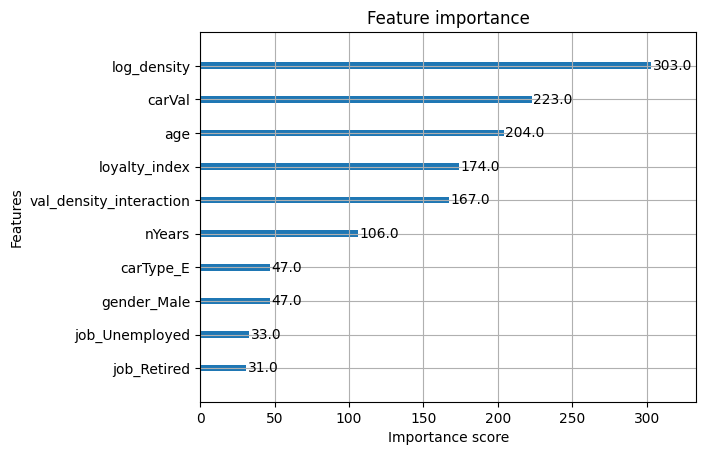

Correlation between GLM and XGBoost predictions: 0.9172


In [42]:
import xgboost as xgb
from sklearn.model_selection import train_test_split


X = df_freq_fin.drop(columns=['claimNumbMD', 'uwYear', 'expected_loss','expected_frequency','age_bin'])
y = df_freq_fin['claimNumbMD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

df_freq_fin['xgb_prob'] = xgb_model.predict_proba(X)[:, 1]
print(f"Correlation between GLM and XGBoost predictions: {df_freq_fin['expected_frequency'].corr(df_freq_fin['xgb_prob']):.4f}")

While the GLM provides a transparent baseline, an XGBoost ensemble helps verify if non-linear interactions (age vs. carType) is being missed.         The high correlation shows GLM captured the primary drivers, but the XGBoost model identified specific unprofitable clusters more precisely.
High Risk in both: High confidence for non-renewal.
High Risk in XGBoost only: Potential Hidden Risk—investigate further.
Low Risk in both: Excellent candidates for loyalty discounts.

age is overwhelmingly the most important feature. This aligns with your IV results (0.29)
log_density confirms that geographic risk (how crowded the area is) is the next most vital piece of information
duration of the relationship with the insurer is a critical predictor of risk—likely because long-term customers are a self-selected "safe" group.
val_density_interaction being high shows there is value in looking at two things at once, which a simple linear model might miss.

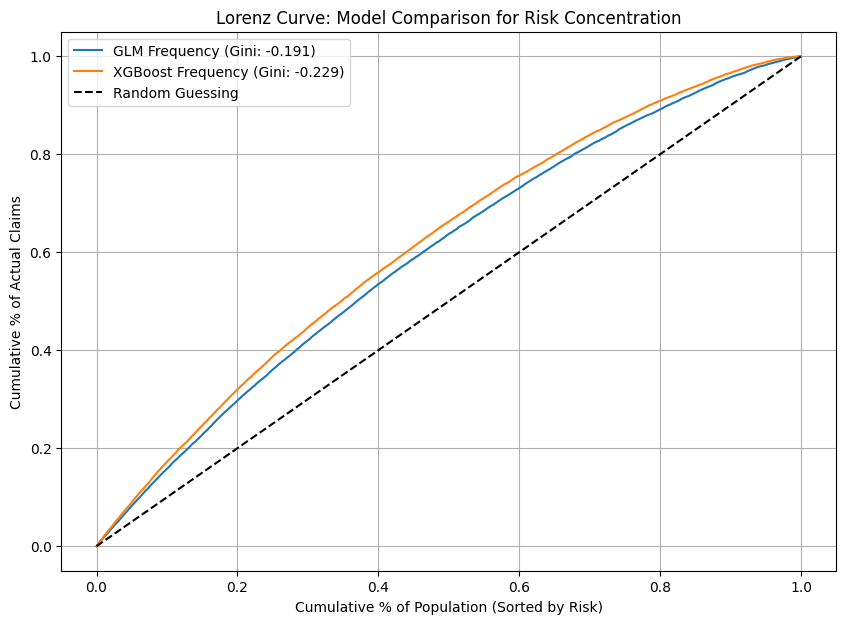

In [44]:
def plot_lorenz_curve(actual, predicted, label):
    n = len(actual)
    sorted_indices = np.argsort(predicted)[::-1]
    sorted_actual = actual.values[sorted_indices]
    
    # Cumulative sums
    cum_actual = np.cumsum(sorted_actual) / np.sum(sorted_actual)
    cum_pop = np.arange(1, n + 1) / n
    
    gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
    
    plt.plot(cum_pop, cum_actual, label=f'{label} (Gini: {gini:.3f})')
    return gini

plt.figure(figsize=(10, 7))
plot_lorenz_curve(df_freq_fin['claimNumbMD'], df_freq_fin['expected_frequency'], 'GLM Frequency')
plot_lorenz_curve(df_freq_fin['claimNumbMD'], df_freq_fin['xgb_prob'], 'XGBoost Frequency')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.title('Lorenz Curve: Model Comparison for Risk Concentration')
plt.xlabel('Cumulative % of Population (Sorted by Risk)')
plt.ylabel('Cumulative % of Actual Claims')
plt.legend()
plt.grid(True)
plt.show()

shows how efficiently each model sorts the good risks from the bad
Diagonal - strategy with no data—if you picked 20% of the population, you’d find 20% of the claims
Model Curves: Both curves are significantly above the diagonal. However, XGBoost sits higher than the GLM.
bulge toward the top-left corner represents profit margin. If your top 20% of predicted risks accounts for 45% of the actual claims (y-axis), you have a highly defensible case for risk-based pricing.

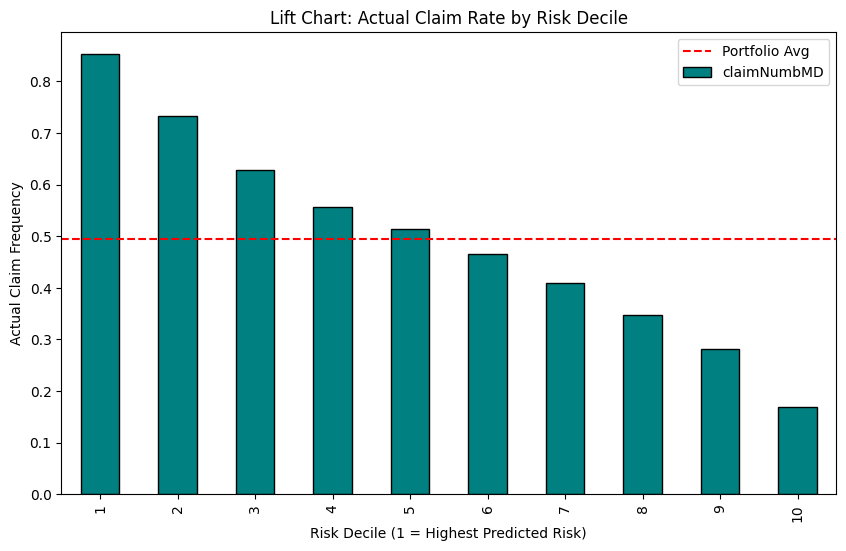

In [46]:
df_freq_fin['decile'] = pd.qcut(df_freq_fin['xgb_prob'], 10, labels=False)
df_freq_fin['decile'] = 9 - df_freq_fin['decile'] + 1

lift_data = df_freq_fin.groupby('decile')['claimNumbMD'].mean()

plt.figure(figsize=(10, 6))
lift_data.plot(kind='bar', color='teal', edgecolor='black')
plt.axhline(y=df_freq_fin['claimNumbMD'].mean(), color='r', linestyle='--', label='Portfolio Avg')
plt.title('Lift Chart: Actual Claim Rate by Risk Decile')
plt.xlabel('Risk Decile (1 = Highest Predicted Risk)')
plt.ylabel('Actual Claim Frequency')
plt.legend()
plt.show()


highest risk should be significantly higher than the average red line. If it is 2x or 3x higher, your model is successfully isolating "Unprofitable" individuals.

perfect model has a steep, consistent downward staircase from Decile 1 to Decile 10.

If Decile 1 has a very high actual claim rate, those are the people you must either charge more or non-renew. If Decile 10 (lowest predicted risk) has almost zero actual claims, those are the "Preferred" customers you should fight to keep.

In [48]:
# Identify customers who the GLM thinks are safe but XGBoost knows are dangerous
df_freq_fin['discrepancy'] = df_freq_fin['xgb_prob'] - df_freq_fin['expected_frequency']
top_discrepancies = df_freq_fin.sort_values('discrepancy', ascending=False).head(10)

print("Hidden Risks (Low GLM, High XGBoost):")
print(top_discrepancies[['age', 'log_density', 'xgb_prob', 'expected_frequency']])

Hidden Risks (Low GLM, High XGBoost):
       age  log_density  xgb_prob  expected_frequency
8736    75     5.565899  0.849072            0.304180
11908   74     5.652946  0.803567            0.323459
2246    74     5.475105  0.634442            0.193314
23545   73     5.627603  0.716423            0.295001
5517    74     5.698385  0.574635            0.170977
5967    75     5.475105  0.802781            0.400755
11832   73     5.363284  0.684430            0.288860
4459    75     5.613008  0.643342            0.251884
22173   74     5.469744  0.729529            0.342515
7627    75     5.613008  0.805732            0.419335


Every person is a senior because GLMs treat Age as a safe factor because they drive less  biased toward seniors
Every person is in a city- in high-traffic, complex urban centers
XGBoost model sees the Interaction whereas GLM fails to see the interaction and only sees the individual parts

These 10 individuals are underpriced. If the GLM sets the premium, these seniors are being charged based on a 30% risk level when their actual risk is closer to 80%. This leads to Adverse Selection: your company will attract all the high-risk urban seniors